# 02 The Murmuration

The phenomenon itself, before any machine learning: average the Frobenius traces over thousands of elliptic curves of fixed rank, and a bare oscillation appears — mirror-imaged between rank 0 and rank 1, shifted for rank 2. This notebook recreates HLOP's most striking visualizations (the murmurations of Figs 6–7 and the Hasse-normalized histograms of Figs 9–11) and closes with the paper's curve fits (Section 4.5): the oscillation is well described by $A\,p^{\alpha}\sin(B\,p^{\beta})$ with $\beta \approx \tfrac{1}{2}$.

No questions are posed here — the classification and mechanism studies live in Notebooks 03–06. This is the phenomenon they are about.

In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from murmurations.features import average_ap_by_rank, normalized_ap
from murmurations.ml import fit_gr
from murmurations.plots import (
    plot_ap_histograms,
    plot_curve_fit,
    plot_murmuration,
)

DATA = Path("..") / "data"
ec_7500_10000 = pd.read_parquet(DATA / "ec_7500_10000_r012_1000ap.parquet")

## $f_0(n)$ vs $f_1(n)$ — the mirror-image oscillation (Fig 6)

In README.md, we defined the set
$$
\mathcal{E}[N_{1}, N_{2}] : = \{ E / \mathbb{Q} : N_{1} \leq N(E) \leq N_{2} \} \, .
$$

For a non-negative integer $r$, define $\mathcal{E}_{r}[N_{1}, N_{2}]$ to be the subset of (representatives of isogeny classes of) elliptic curves in $\mathcal{E}[N_{1}, N_{2}]$ of rank $r$
$$
\mathcal{E}_{r}[N_{1}, N_{2}] : = \{ E / \mathbb{Q} : N_{1} \leq N(E) \leq N_{2} \text{ and } r_{E} = r\} \, ,
$$
and define the function $f_{r}(n)$ by
$$
f_{r}(n) : = \frac{1}{\# \mathcal{E}_{r}[N_{1}, N_{2}]} \sum_{E \in \mathcal{E}_{r}[N_{1}, N_{2}]} a_{p_{n}}(E) \, .
$$

Below we plot $f_{0}(n)$ and $f_{1}(n)$ for $1 \leq n \leq 1000$ and $[N_{1}, N_{2}] = [7500, 10000]$ — the mirror-image oscillation of HLOP Fig 6 — then add $f_{2}(n)$.

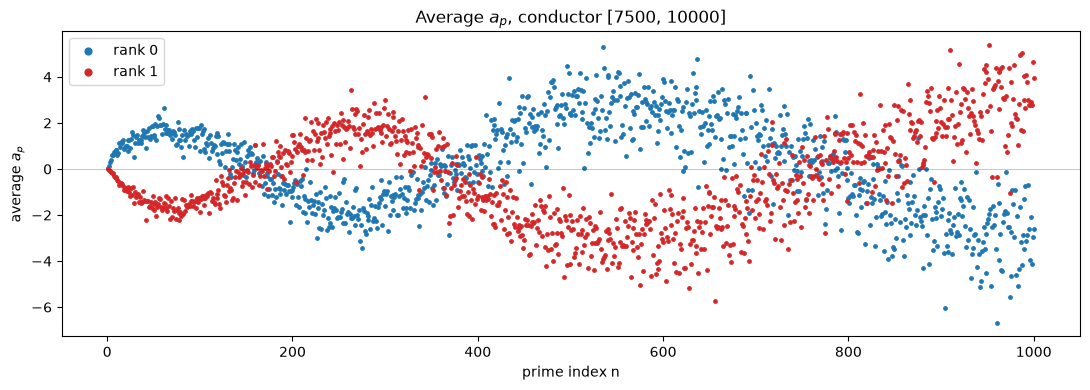

In [2]:
favg = average_ap_by_rank(ec_7500_10000, ranks=[0, 1, 2])
plot_murmuration(
    favg, ranks=[0, 1], title="Average $a_p$, conductor [7500, 10000]"
)
plt.tight_layout()
plt.show()

### Add rank 2 — Fig 7 analogue

HLOP's Fig 7 widens the conductor range to [5000, 10000] to gather 1380 rank-2 curves; we stay on [7500, 10000] (771 rank-2 curves), so this is the same comparison on our narrower window. Note the paper's observation that smaller conductors raise the oscillation frequency — our narrower, higher window should oscillate slightly slower than their Fig 7.

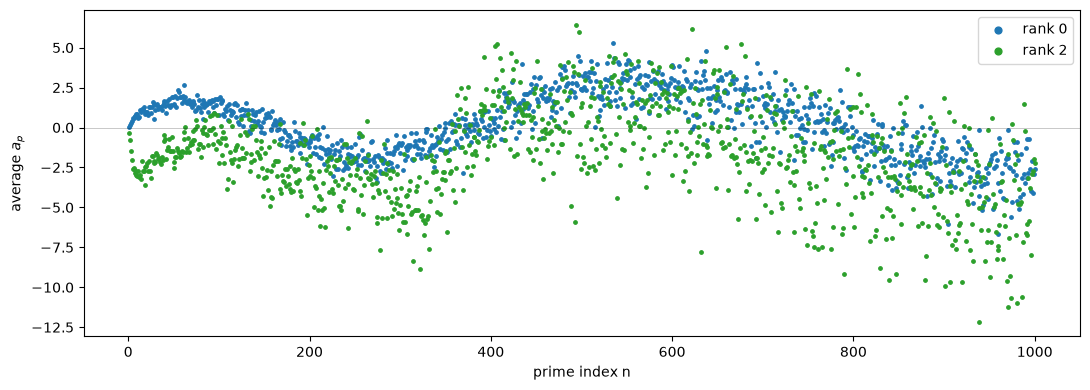

In [3]:
# favg holds all three ranks; the plot's `ranks` selects which to draw
# (rank 1 omitted here, matching the paper's Fig 7 layout).
plot_murmuration(favg, ranks=[0, 2])
plt.tight_layout()
plt.show()

### Normalized $\tilde a_p = a_p / (2\sqrt p)$ distributions (Figs 9-11)
For small primes {11,13,17,19} (prime indices 5,6,7,8).

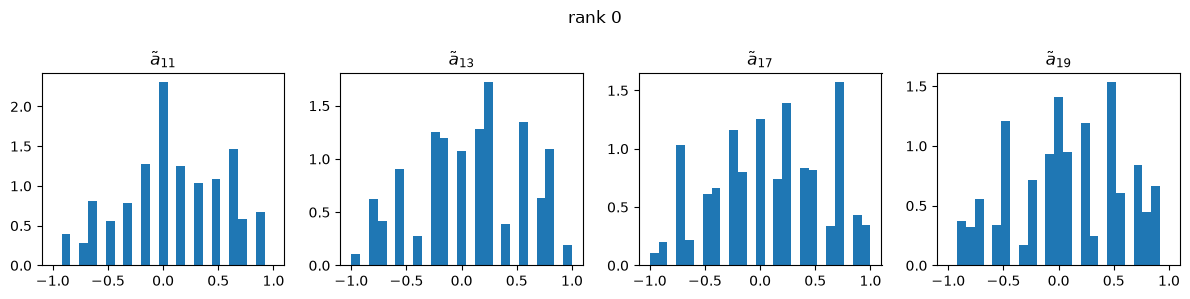

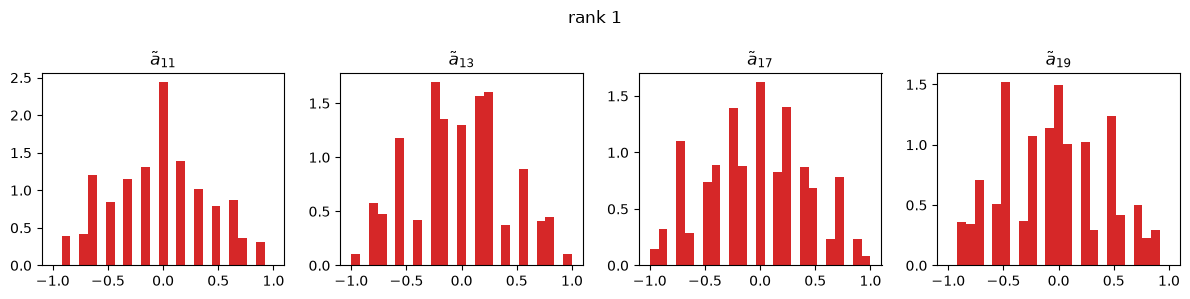

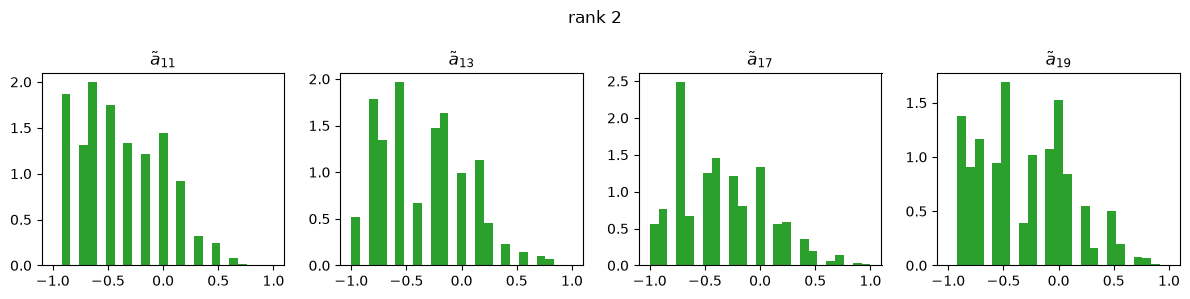

In [4]:
for r in [0, 1, 2]:
    axes = plot_ap_histograms(
        ec_7500_10000,
        prime_indices=[5, 6, 7, 8],
        rank=r,
        normalize_fn=normalized_ap,
    )
    axes[0].figure.suptitle(f"rank {r}")
    plt.tight_layout()
    plt.show()

## Curve fitting (Section 4.5, Figs 13–16)

Reindexing by the prime $p$ rather than the index $n$ gives $g_r(p)$:
$$
g_{r}(p) : = \frac{1}{\# \mathcal{E}_{r}[N_{1}, N_{2}]} \sum_{E \in \mathcal{E}_{r}[N_{1}, N_{2}]} a_{p}(E) \, .
$$

HLOP fit 
$$
y = A x^{\alpha} \sin(B x^{\beta})
$$ 
(Eq. 4.10) and find $\beta \approx 0.5$ and $\alpha \approx 0.2$ in every window (Table 2): the oscillation is essentially sinusoidal in $\sqrt p$ with a slowly growing amplitude.

Two differences from the paper's figures: HLOP fit narrow 1000-wide windows out to $p \approx 27500$, while our cached vectors stop at $p_{1000} = 7919$ and our window [7500, 10000] is 2.5× wider — so compare the fitted parameters loosely against Table 2's [7000, 8000] and [8000, 9000] rows, not exactly.

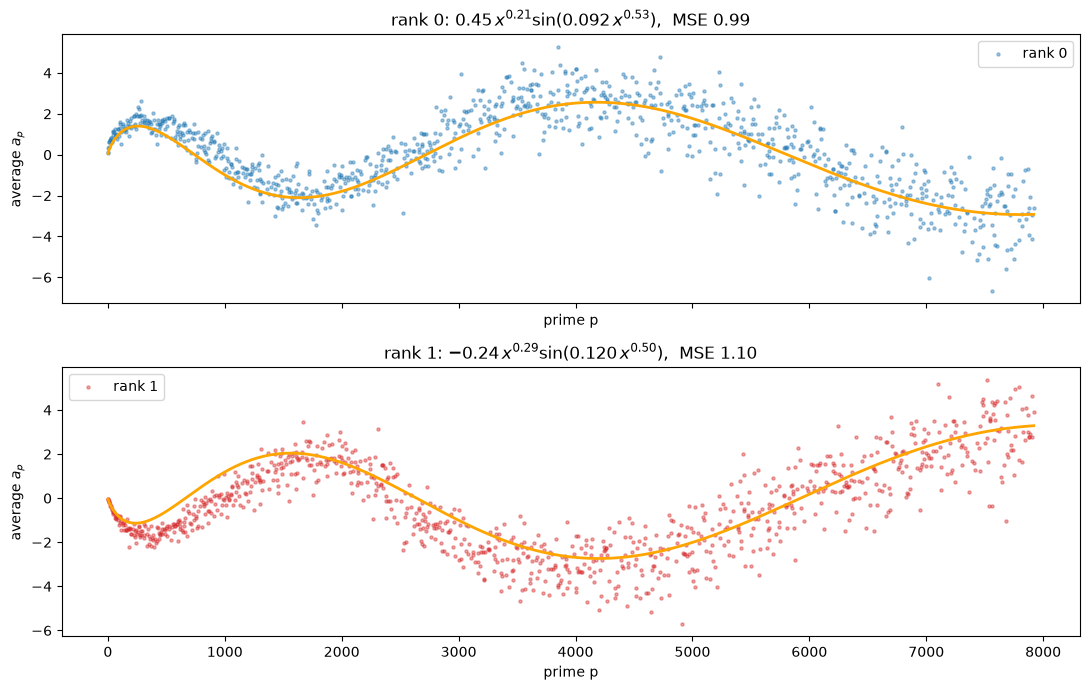

In [5]:
p = favg["p"].to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, r, color in [(axes[0], "0", "tab:blue"), (axes[1], "1", "tab:red")]:
    g = favg[r].to_numpy()
    fit = fit_gr(p, g)
    plot_curve_fit(p, g, fit, color=color, ax=ax, label=f"rank {r}")
    A, alpha, B, beta = fit.params
    ax.set_title(
        rf"rank {r}: ${A:.2f}\,x^{{{alpha:.2f}}}"
        rf"\sin({B:.3f}\,x^{{{beta:.2f}}})$,  MSE {fit.mse:.2f}"
    )
    ax.legend()
plt.tight_layout()
plt.show()

Both fits match HLOP's observations that $\beta \approx 0.5$ and $\alpha \approx 0.2$.